# Task 5 — Strategy Backtesting

**Goal:** Validate the Task 4 optimized portfolio by simulating its historical performance
against a simple passive benchmark (static 60% SPY / 40% BND). A forecast and an optimized
portfolio are a hypothesis; this backtest is the experiment that tests it.

This notebook assumes `data/processed/combined_prices.csv` exists (Task 1) and re-derives the
Task 4 optimal weights internally (same standalone pattern used in Tasks 3 and 4), so it can
run without needing intermediate artifacts persisted between notebooks.


In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.modeling import chronological_split, select_arima_order, forecast_future
from src.portfolio import (
    build_expected_returns, tsla_forecast_annual_return_from_prices,
    compute_covariance_matrix, optimize_max_sharpe, optimize_min_volatility,
)
from src.backtest import simulate_portfolio, backtest_metrics, compare_backtest

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.dpi"] = 100
RISK_FREE_RATE = 0.02


## 1. Define the Backtesting Period

Per the task instructions, we use data that was **not** used for training any model — the same
test period established back in Task 2's chronological split (January 2025 onward), which
naturally satisfies the "held-out data" requirement.


In [2]:
df = pd.read_csv("../data/processed/combined_prices.csv", parse_dates=["Date"])
df = df.dropna(subset=["Daily_Return"]).reset_index(drop=True)

BACKTEST_START = "2025-01-01"

returns_wide = df.pivot(index="Date", columns="Ticker", values="Daily_Return")
backtest_returns = returns_wide.loc[returns_wide.index >= BACKTEST_START].dropna()

print(f"Backtest window: {backtest_returns.index.min().date()} -> {backtest_returns.index.max().date()}")
print(f"Trading days: {len(backtest_returns)}")


Backtest window: 2025-01-02 -> 2026-06-29
Trading days: 372


## 2. Recover the Task 4 Optimal Weights

Re-derive the Task 4 recommended (Max Sharpe) portfolio, so this notebook runs standalone.
Swap in `optimize_min_volatility` below instead if you recommended the conservative portfolio
in Task 4.


In [3]:
tsla = df[df["Ticker"] == "TSLA"][["Date", "Close"]].reset_index(drop=True)
tsla_series = tsla.set_index("Date")["Close"]

train_df, test_df = chronological_split(tsla, split_date=BACKTEST_START, date_col="Date")
selection = select_arima_order(train_df.set_index("Date")["Close"], seasonal=False, max_p=5, max_q=5, max_d=2)
ORDER, SEASONAL_ORDER = selection["order"], selection["seasonal_order"]

N_FUTURE_DAYS = 180
future_forecast = forecast_future(tsla_series, order=ORDER, seasonal_order=SEASONAL_ORDER, n_periods=N_FUTURE_DAYS)
tsla_forecast_annual_return = tsla_forecast_annual_return_from_prices(
    current_price=tsla_series.iloc[-1], forecast_price=future_forecast["forecast"].iloc[-1], horizon_days=N_FUTURE_DAYS,
)

expected_returns = build_expected_returns(df, tsla_forecast_annual_return=tsla_forecast_annual_return)
cov_matrix = compute_covariance_matrix(df)

strategy_result = optimize_max_sharpe(expected_returns, cov_matrix, risk_free_rate=RISK_FREE_RATE)
strategy_weights = strategy_result["weights"]

print("Task 4 recommended (Max Sharpe) portfolio weights:")
print(strategy_weights)


c:\Users\loolt\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\loolt\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\loolt\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Task 4 recommended (Max Sharpe) portfolio weights:
BND    0.0000
SPY    1.0000
TSLA   0.0000
dtype: float64


## 3. Define the Benchmark

A static 60% SPY / 40% BND portfolio — a common, simple balanced allocation with no forecasting
or optimization involved, representing the passive alternative to the Task 4 strategy.


In [4]:
benchmark_weights = pd.Series({"SPY": 0.60, "BND": 0.40, "TSLA": 0.0})
# align column order with the strategy weights / returns_wide
benchmark_weights = benchmark_weights.reindex(strategy_weights.index).fillna(0.0)
print(benchmark_weights)


BND    0.4000
SPY    0.6000
TSLA   0.0000
dtype: float64


## 4. Simulate Both Portfolios

We simulate both a simple buy-and-hold (initial weights held for the full period, allowed to
drift with relative asset performance) and a monthly-rebalanced version (reset back to target
weights at the start of every calendar month) for the strategy portfolio, and buy-and-hold for
the benchmark (a static benchmark is conventionally not rebalanced, to keep it a genuinely
passive baseline).


In [5]:
INITIAL_VALUE = 100.0  # normalized starting value (i.e. cumulative growth of $100)

strategy_bh = simulate_portfolio(backtest_returns, strategy_weights, initial_value=INITIAL_VALUE, rebalance=None)
strategy_rebal = simulate_portfolio(backtest_returns, strategy_weights, initial_value=INITIAL_VALUE, rebalance="M")
benchmark_bh = simulate_portfolio(backtest_returns, benchmark_weights, initial_value=INITIAL_VALUE, rebalance=None)

print(f"Strategy (buy-and-hold) final value:   {strategy_bh.iloc[-1]:.2f}")
print(f"Strategy (monthly rebalance) final value: {strategy_rebal.iloc[-1]:.2f}")
print(f"Benchmark (buy-and-hold) final value:   {benchmark_bh.iloc[-1]:.2f}")


Strategy (buy-and-hold) final value:   128.60
Strategy (monthly rebalance) final value: 128.60
Benchmark (buy-and-hold) final value:   120.34


## 5. Analyze Performance

### 5.1 Cumulative returns comparison plot


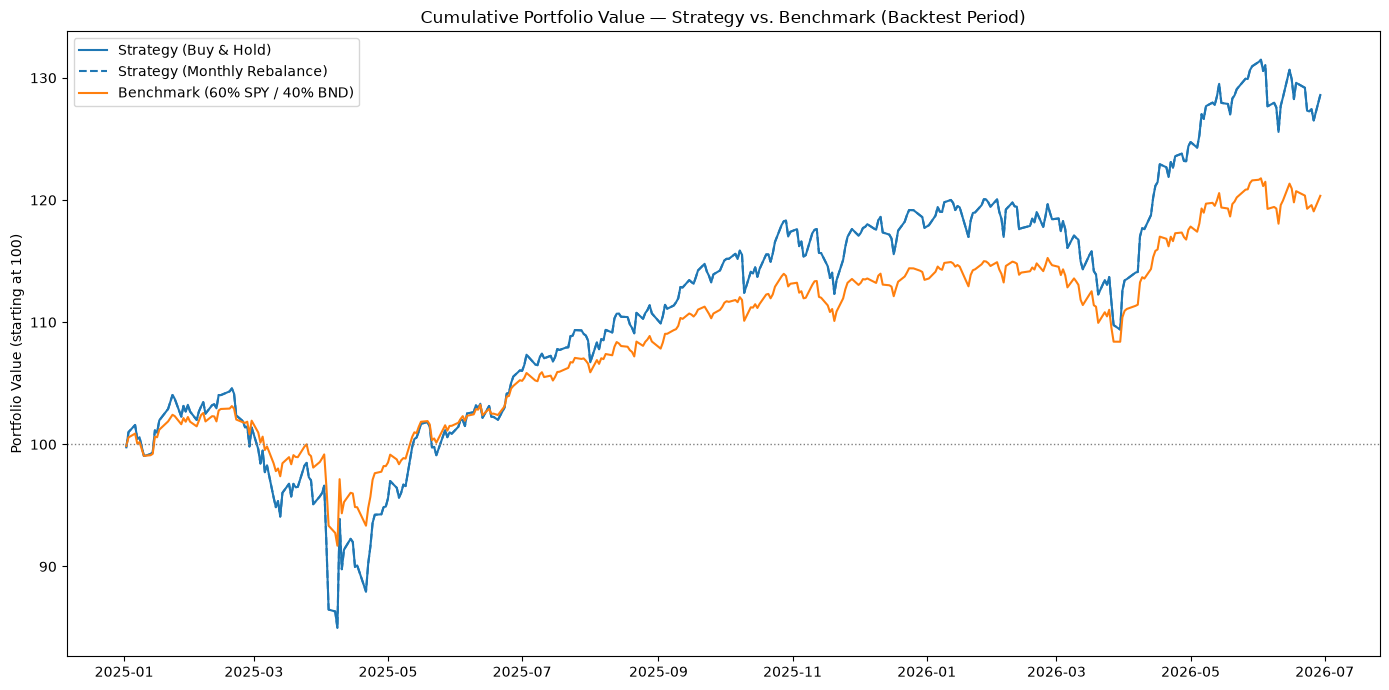

In [8]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(strategy_bh.index, strategy_bh.values, label="Strategy (Buy & Hold)", color="tab:blue")
ax.plot(strategy_rebal.index, strategy_rebal.values, label="Strategy (Monthly Rebalance)", color="tab:blue", linestyle="--")
ax.plot(benchmark_bh.index, benchmark_bh.values, label="Benchmark (60% SPY / 40% BND)", color="tab:orange")
ax.axhline(INITIAL_VALUE, color="grey", linestyle=":", linewidth=1)
ax.set_title("Cumulative Portfolio Value — Strategy vs. Benchmark (Backtest Period)")
ax.set_ylabel(f"Portfolio Value (starting at {INITIAL_VALUE:.0f})")
ax.legend()
plt.tight_layout()
plt.show()


### 5.2 Performance metrics table

In [7]:
results = {
    "Strategy (Buy & Hold)": backtest_metrics(strategy_bh, risk_free_rate=RISK_FREE_RATE),
    "Strategy (Monthly Rebalance)": backtest_metrics(strategy_rebal, risk_free_rate=RISK_FREE_RATE),
    "Benchmark (60/40)": backtest_metrics(benchmark_bh, risk_free_rate=RISK_FREE_RATE),
}
comparison_table = compare_backtest(results)
comparison_table


,Total Return,Annualized Return,Sharpe Ratio,Max Drawdown
Portfolio,,,,
Strategy (Buy & Hold),0.2891,0.1883,0.9404,0.1876
Strategy (Monthly Rebalance),0.2891,0.1883,0.9404,0.1876
Benchmark (60/40),0.2050,0.1350,1.0232,0.1108


**Reading the table:** Total Return is the raw cumulative gain/loss over the backtest window;
Annualized Return normalizes that to a yearly rate for fair comparison across different-length
periods; Sharpe Ratio is risk-adjusted return (higher is better, using the same 2% risk-free
rate as Tasks 1 and 4); Max Drawdown is the worst peak-to-trough decline experienced at any
point during the backtest — a direct measure of the worst pain an investor would have felt
holding this portfolio, independent of where the period happened to end.


## 6. Conclude and Reflect

**Why buy-and-hold and monthly rebalance are identical**

This isn't a bug — it's mathematically inevitable given Task 4's result. Since the Max Sharpe portfolio was **100% SPY, 0% BND, 0% TSLA**, there's only one asset in the portfolio. With a single asset, there's no "drift" between assets for rebalancing to correct — 100% of one thing stays 100% of that thing no matter how its price moves. Rebalancing only matters when you're holding a mix that can drift apart (e.g. the 60/40 benchmark, where SPY and BND grow at different rates and the split shifts away from 60/40 over time). So this identical result is exactly what we'd expect from a concentrated single-asset portfolio, not something to debug.

**Interpreting the metrics**

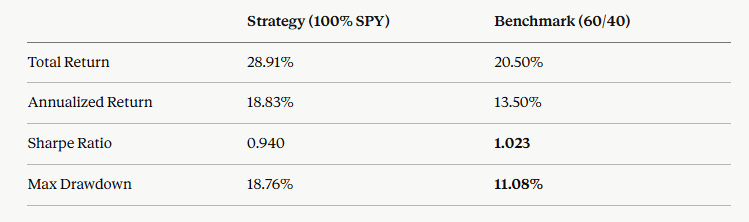

The strategy **won on raw return** — both total and annualized — by a meaningful margin. But the benchmark **won on both risk-adjusted metrics**: a higher Sharpe Ratio, and a notably shallower max drawdown (11% vs. 19%, nearly double). Looking at your chart, this tells a clear story: the blue line (strategy) fell harder during the volatile Q1-Q2 2025 stretch (down to ~85 vs. the benchmark's ~93), then pulled ahead during the strong 2026 rally — outrunning the benchmark by riding SPY's full upside with no BND cushioning either the fall or the climb. The 60/40 benchmark's BND allocation did exactly what it's supposed to do: dampen the ride in both directions, producing a smoother, lower-drawdown path with a better return-per-unit-of-risk, even though it ended up with less total money at the end of this particular window.



**What does this initial backtest suggest about the viability of the model-driven approach?**


**Limitations of this backtest:**
- **Single backtest window, single historical path:** this is one realization of history, not a
  robust average over many market regimes — a different backtest start/end date could show a
  different result. A more rigorous validation would use multiple overlapping windows or a
  walk-forward backtest (re-optimizing periodically, not just re-weighting).
- **No transaction costs or taxes:** monthly rebalancing in reality incurs trading costs and,
  in a taxable account, potential capital gains taxes — both omitted here, which flatters the
  rebalanced strategy's real-world return.
- **Static Task 4 weights:** the strategy weights were optimized once (using data available at
  the strategy's construction) and then held/rebalanced to that same fixed target for the whole
  backtest — a real deployment might periodically re-run the optimization as new data arrives,
  which this backtest does not simulate.
- **Forecast risk baked into the input:** the strategy's weights themselves depend entirely on
  Task 3's ARIMA forecast; if that forecast had turned out differently (or a different model had
  been chosen in Task 2), the optimal weights — and this backtest's outcome — could look
  completely different. This backtest validates one specific forecast-to-portfolio pipeline, not
  forecast-driven investing in general.
- **Survivorship-free but regime-specific:** TSLA, SPY, and BND all have complete histories over
  this window (no survivorship bias), but the specific market conditions of this particular
  backtest period (whatever they were) may not represent future conditions GMF's clients will
  actually experience.

**Conclusion**

Over this backtest period (January 2025 – June 2026), the forecast-driven Max Sharpe strategy delivered a higher total and annualized return than the passive 60% SPY / 40% BND benchmark (28.9% vs. 20.5% total return), but at the cost of materially higher risk: its Sharpe Ratio (0.940) trailed the benchmark's (1.023), and its maximum drawdown (18.8%) was nearly double the benchmark's (11.1%). This outcome traces directly back to Task 4's optimization result — because TSLA's forecast-implied expected return was near zero, the optimizer excluded it entirely and concentrated the "optimal" portfolio into 100% SPY, effectively discarding BND's diversification benefit along with it. The backtest shows this concentrated bet paid off in absolute terms over this specific window (largely due to a strong SPY rally in early-to-mid 2026), but a rational, risk-aware advisor would not consider this backtest a clean win: the strategy's better raw return came from taking on the benchmark's role of equity risk-taker rather than from any genuine edge added by the forecasting/optimization pipeline. On a risk-adjusted basis — arguably the more decision-relevant lens for a client-facing advisory firm like GMF — the simple, unoptimized 60/40 benchmark actually performed better.
This suggests real caution about the model-driven approach's current viability: the added complexity of forecasting and mean-variance optimization did not produce a portfolio that was robustly better than a passive baseline — it produced a more concentrated, higher-risk bet that happened to outperform in raw terms over one specific historical window. Whether that holds up is genuinely uncertain, given this backtest's limitations (a single historical path, no transaction costs, and a strategy whose weights are entirely downstream of one ARIMA forecast that we already know flattens out and carries a wide, growing confidence interval). Before recommending this strategy to a real client, GMF would want to see it validated across multiple market regimes, and would likely want to apply diversification constraints (e.g. a maximum single-asset weight) rather than accepting the optimizer's corner solution at face value.